In [1]:
include("RCP3BP.jl")
using Plots

In [2]:
mu = 0.4
A_L4 = X_H(mu)
A_L5 = [0 1 1 0; -1 0 0 1; -0.25 -0.75*sqrt(3)*(1-2*mu) 0 1; -0.75*sqrt(3)*(1-2*mu) 1.25 -1 0]

vaps_L4 = eigenValues(mu)
veps_L4 = eigenVectors(mu)

4-element Vector{Vector{ComplexF64}}:
 [0.6655146964758234 + 0.0im, 0.03728288755605451 + 0.47155788800193144im, 0.3764061563742801 + 0.1550149574682878im, 0.24472482201593707 + 0.32822532386646674im]
 [0.6655146964758234 - 0.0im, 0.03728288755605451 - 0.47155788800193144im, 0.3764061563742801 - 0.1550149574682878im, 0.24472482201593707 - 0.32822532386646674im]
 [0.635673266203118 + 0.0im, -0.1373004931074141 + 0.4936949867010883im, -0.25783888869764915 + 0.10478256654210251im, 0.25621333207364194 - 0.43615110113934824im]
 [0.635673266203118 - 0.0im, -0.1373004931074141 - 0.4936949867010883im, -0.25783888869764915 - 0.10478256654210251im, 0.25621333207364194 + 0.43615110113934824im]

In [3]:
vaps_L5 = reverse(eigvals(A_L5))
veps = eigvecs(A_L5)
veps_L5 = [veps[:,4],veps[:,3],veps[:,2],veps[:,1]]

4-element Vector{Vector{ComplexF64}}:
 [0.635673266203118 + 0.0im, 0.1373004931074141 + 0.4936949867010883im, 0.25783888869764915 + 0.10478256654210251im, 0.25621333207364194 + 0.43615110113934824im]
 [0.635673266203118 - 0.0im, 0.1373004931074141 - 0.4936949867010883im, 0.25783888869764915 - 0.10478256654210251im, 0.25621333207364194 - 0.43615110113934824im]
 [-0.6655146964758234 + 0.0im, 0.03728288755605451 - 0.47155788800193144im, 0.3764061563742801 - 0.1550149574682878im, -0.24472482201593707 + 0.32822532386646674im]
 [-0.6655146964758234 - 0.0im, 0.03728288755605451 + 0.47155788800193144im, 0.3764061563742801 + 0.1550149574682878im, -0.24472482201593707 - 0.32822532386646674im]

In [4]:
s = Sistem(mu)

Ivecs = real([veps_L5[1] + veps_L5[2], (veps_L5[1] - veps_L5[2])*im])
Evecs = real([veps_L5[3] + veps_L5[4], (veps_L5[3] - veps_L5[4])*im])
println("vectors inestables L4 i L5")
println(s.Ivecs)
println(Ivecs)
println("\nvectors estables L4 i L5")
println(s.Evecs)
println(Evecs)


vectors inestables L4 i L5
[[1.3310293929516468, 0.07456577511210902, 0.7528123127485602, 0.48944964403187413], [0.0, -0.9431157760038629, -0.3100299149365756, -0.6564506477329335]]
[[1.271346532406236, 0.2746009862148282, 0.5156777773952983, 0.5124266641472839], [0.0, -0.9873899734021766, -0.20956513308420502, -0.8723022022786965]]

vectors estables L4 i L5
[[1.271346532406236, -0.2746009862148282, -0.5156777773952983, 0.5124266641472839], [0.0, -0.9873899734021766, -0.20956513308420502, 0.8723022022786965]]
[[-1.3310293929516468, 0.07456577511210902, 0.7528123127485602, -0.48944964403187413], [0.0, 0.9431157760038629, 0.3100299149365756, -0.6564506477329335]]


In [5]:
#simetrics cruats
println("Diferencia de signes en Inestable")
println(Ivecs[1] ./ s.Evecs[1])
println(Ivecs[2] ./ s.Evecs[2])

println("\nDiferencia de signes en Estable")
println(Evecs[1] ./ s.Ivecs[1])
println(Evecs[2] ./ s.Ivecs[2])

Diferencia de signes en Inestable
[1.0, -1.0, -1.0, 1.0]
[NaN, 1.0, 1.0, -1.0]

Diferencia de signes en Estable
[-1.0, 1.0, 1.0, -1.0]
[NaN, -1.0, -1.0, 1.0]


6.661338147750939e-16
-2.008183253021656e-7


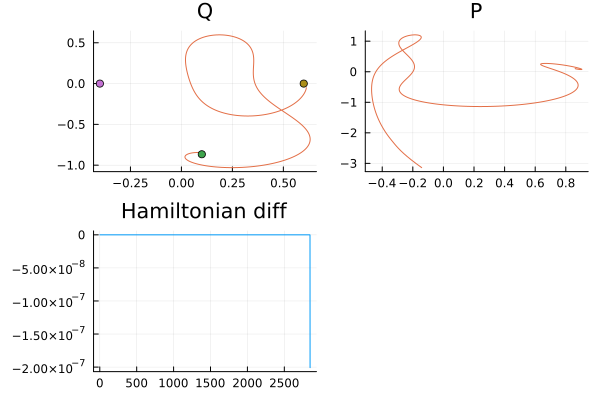

In [8]:
#test de problema estable L5
s1 = [-1, 1, 1, -1]
s2 = [1, -1, -1, 1]
L5 = [0.5-mu,-sqrt(3)/2,sqrt(3)/2,0.5-mu]

theta = 1.0
u0 = L5 + s.eps*(cos(theta)*(s.Ivecs[1] .* s1) + sin(theta)*(s.Ivecs[2] .* s2))
#u0 = L5 + s.eps*(cos(theta)*(s.Ivecs[2]) + sin(theta)*(s.Ivecs[1]))
#u0 = L5 + s.eps*(cos(theta)*Evecs[1] + sin(theta)*Evecs[2]) 
prob = ODEProblem(orbitBack!,u0,(0.0,100.0),mu)
#prob = problemE_L5
callback = end_callback(prob,mu)
sol = solve(prob,Feagin14(),dtmax=0.01,callback = callback)

#plot result
plot(1,legend=false,title="Q")
pltQ = plot!(sol,idxs=(1,2))
pltQ = plot!([L5[1]],[L5[2]],seriestype=:scatter)
pltQ = plot!([-mu],[0],seriestype=:scatter)
pltQ = plot!([1-mu],[0],seriestype=:scatter)
plot(1,legend=false,title="P")
pltP = plot!(sol,idxs=(3,4))
H = []
for u in sol.u
    H = push!(H,hamiltonian((u[3],u[4]),(u[1],u[2]),(mu)))
end

H = H .- H[1]

maxH = maximum(H)
minH = minimum(H)
println(maxH)
println(minH)

pltH = plot(H,legend=false,title="Hamiltonian diff")

plot(pltQ,pltP,pltH)